# Scattering Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Add project root to path
sys.path.append("..")

# Import project modules
from src.dataset.biopsy2_dataset import Biopsy2Dataset
from src.dataset.biopsy1_dataset import Biopsy1Dataset
from src.constants import ALL_PATIENT_IDS, WAVELENGTHS
from src.molecules import Molecules, REFERENCE_SPECTRUM_T1, MoleculeMode, MoleculeIndex
from src.scattering_model.scatter_optim import optimize_image_parallel
from src.visualize_data import plot_inferred_concentrations, get_mean_fat_diff_cco_hbo2, get_mean_fat_diff_cco_diff_hb, get_mean_data
from tqdm import tqdm
from pathlib import Path
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Loaded 59 patient IDs from metadata CSV


## Dataset Setup

In [2]:
COARSENESS = 1
LEFT_CUT = 500
RIGHT_CUT = 900
DOWNSAMPLE_FACTOR = 4

dataset = Biopsy2Dataset(
    reference_spectrum_path="../data/reference/S1_4_1_mean_roi.npy",
    coarseness=COARSENESS,
    left_cut=LEFT_CUT,
    right_cut=RIGHT_CUT,
    with_delta_A=True,
    downsample_factor=DOWNSAMPLE_FACTOR,
)


## Spectral Unmixing

### Setup

In [3]:
save_dir = Path(
    f"../results/spectral_unmixing_avgpool_{COARSENESS}_left_{630}_right_{1015}_ivan"
)
# save_dir.mkdir(parents=True, exist_ok=True)
molecules = Molecules(left_cut=dataset.left_cut, right_cut=dataset.right_cut)
t1_params = [
    REFERENCE_SPECTRUM_T1[MoleculeMode.ALL][0],
    REFERENCE_SPECTRUM_T1[MoleculeMode.ALL][1],
]


### Calculation

In [ ]:
# We load only the sample information and load the cubes later as we have to restart the kernel a lot and this makes it faster to start from scratch
for sample in tqdm(dataset.cube_samples):
    print("Processing sample:", sample["id"])
    orig_path = Path(sample['file_path'])
    sample_dir = save_dir / orig_path.stem

    if sample_dir.exists():
        print(f"Sample {orig_path.stem} already processed. Skipping.")
        continue

    hsi_cube = np.load(sample['file_path'])
    delta_A = dataset._compute_delta_A(hsi_cube=hsi_cube)
    delta_A_flat = delta_A.reshape(-1, delta_A.shape[-1])

    errors, coef_list, scatter_params, _ = optimize_image_parallel(
        t1_params, delta_A_flat, molecules.M, dataset.cut_wavelengths
    )

    # --- Store results for each sample ---
    # Get original file name without extension
    sample_dir.mkdir(parents=True, exist_ok=True)

    # Save errors, coef_list, scatter_params as .npy files
    np.save(sample_dir / 'errors.npy', errors)
    np.save(sample_dir / 'coef_list.npy', coef_list)
    np.save(sample_dir / 'scatter_params.npy', scatter_params)

Cut wavelengths: [ 625.  630.  635.  640.  645.  650.  655.  660.  665.  670.  675.  680.
  685.  690.  695.  700.  705.  710.  715.  720.  725.  730.  735.  740.
  745.  750.  755.  760.  765.  770.  775.  780.  785.  790.  795.  800.
  805.  810.  815.  820.  825.  830.  835.  840.  845.  850.  855.  860.
  865.  870.  875.  880.  885.  890.  895.  900.  905.  910.  915.  920.
  925.  930.  935.  940.  945.  950.  955.  960.  965.  970.  975.  980.
  985.  990.  995. 1000. 1005. 1010. 1015.]
(79,)


## Ivan's method

In [ ]:
import torch.nn.functional as F

reference_S1 = np.load("../data/reference/S1_mean_roi.npy")
print("Reference S1 shape:", reference_S1.shape)
for sample in tqdm(dataset.cube_samples):
    print("Processing sample:", sample["id"])
    orig_path = Path(sample["file_path"])
    sample_dir = save_dir / orig_path.stem

    if sample_dir.exists():
        print(f"Sample {orig_path.stem} processed. Skipping.")
        continue

    hsi_cube = dataset._load_hsi_cube(sample["file_path"])
    hsi_cube_reduced_wl = hsi_cube[48:, :, :]
    hsi_cube_reduced_wl = np.where(
        hsi_cube_reduced_wl <= 0, 10**-3, hsi_cube_reduced_wl
    )

    # Convert to torch tensors
    hsi_tensor = torch.from_numpy(hsi_cube_reduced_wl).float()  # shape: (bands, H, W)
    # Move bands to last dimension for pooling: (H, W, bands)
    hsi_tensor = hsi_tensor.permute(1, 2, 0).unsqueeze(0)  # shape: (1, H, W, bands)
    hsi_tensor = hsi_tensor.permute(0, 3, 1, 2)  # shape: (1, bands, H, W)

    # Downsample spatially
    downsampled = F.avg_pool2d(hsi_tensor, kernel_size=dataset.coarseness)
    downsampled = (
        downsampled.squeeze(0).permute(1, 2, 0).numpy()
    )  # shape: (H', W', bands)

    delta_A = -np.log(downsampled / reference_S1)
    delta_A_flat = delta_A.reshape(-1, delta_A.shape[-1])
    cut_wavelengths = WAVELENGTHS[48:]
    errors, coef_list, scatter_params, _ = optimize_image_parallel(
        t1_params, delta_A_flat, molecules.M, cut_wavelengths, 8
    )

    # --- Store results for each sample ---
    # Get original file name without extension
    sample_dir.mkdir(parents=True, exist_ok=True)

    # Save errors, coef_list, scatter_params as .npy files
    np.save(sample_dir / "errors.npy", errors)
    np.save(sample_dir / "coef_list.npy", coef_list)
    np.save(sample_dir / "scatter_params.npy", scatter_params)

Reference S1 shape: (79,)


  0%|          | 0/50 [00:00<?, ?it/s]

Processing sample: 1.10_1
Sample HyperProbe1.1_Biopsy_S1.10_FOV1 processed. Skipping.
Processing sample: 1.11_1
Sample HyperProbe1.1_Biopsy_S1.11_FOV1 processed. Skipping.
Processing sample: 1.17_1
Sample HyperProbe1.1_Biopsy_S1.17 processed. Skipping.
Processing sample: 1.18_1
Sample HyperProbe1.1_Biopsy_S1.18 processed. Skipping.
Processing sample: 1.19_1
Sample HyperProbe1.1_Biopsy_S1.19 processed. Skipping.
Processing sample: 1.1_1
Sample HyperProbe1.1_Biopsy_S1.1 processed. Skipping.
Processing sample: 1.20_1
Sample HyperProbe1.1_Biopsy_S1.20_FOV1 processed. Skipping.
Processing sample: 1.21_1
Sample HyperProbe1.1_Biopsy_S1.21_FOV1_BIS processed. Skipping.
Processing sample: 1.24_1
Sample HyperProbe1.1_Biopsy_S1.24 processed. Skipping.
Processing sample: 1.27_3
Sample HyperProbe1.1_Biopsy_S1.27_FOV3 processed. Skipping.
Processing sample: 1.28_1
Sample HyperProbe1.1_Biopsy_S1.28_FOV1 processed. Skipping.
Processing sample: 1.2_1
Sample HyperProbe1.1_Biopsy_S1.2_FOV1 processed. Ski

 34%|███▍      | 17/50 [03:20<06:28, 11.78s/it]

Processing sample: 1.33_1


## Compute delta_A from delta_c

In [8]:
from src.scattering_model.scatter import compute_delta_A_img

id = "1.2_1"
delta_c, scatter_params = dataset.load_delta_c_and_scatter_params(
    id=id,
    load_from_path="../results/biopsy2_spectral_unmixing/spectral_unmixing_avgpool_4_coarseness_1_left_500_right_900_reduced_wl_set",
)

delta_A = dataset.get_sample_by_id(id=id)["delta_A"]

scatter_delta_c = delta_c.reshape(delta_A.shape[0], delta_A.shape[1], -1)
scatter_params = scatter_params.reshape(delta_A.shape[0], delta_A.shape[1], -1)

modeled_delta_A = compute_delta_A_img(
    M=molecules.M,
    delta_c=scatter_delta_c,
    a=scatter_params[:, :, 0],
    b=scatter_params[:, :, 1],
    a_0=t1_params[0],
    b_0=t1_params[1],
    x=dataset.cut_wavelengths,
)

## Display inferred concentrations

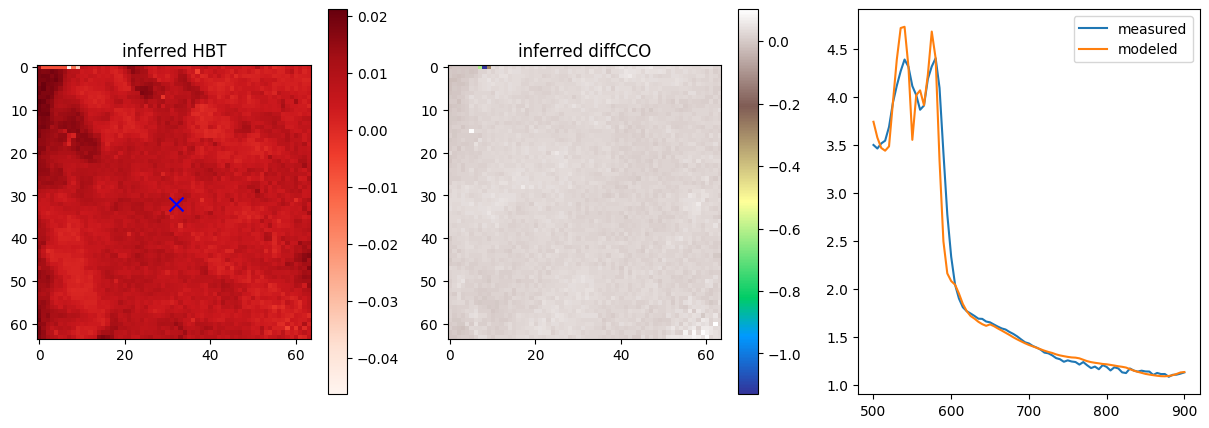

In [9]:
spectrum_pxl = 32, 32

plot_inferred_concentrations(
    spectrum_pxl, scatter_delta_c, delta_A, modeled_delta_A, dataset.cut_wavelengths, coarseness=8
)

## Display separation Map based on concentrations

### Mean fat vs Mean diffCCO

### Mean diffCCo vs Mean HbO2

Sample 1.12_1, Grade 2:
Sample 1.13_1, Grade 4:
Sample 1.14_1, Grade 4:
Sample 1.15_1, Grade 4:
Sample 1.16_1, Grade 1:
Sample 1.1_1, Grade 4:
Sample 1.24_1, Grade 4:
Sample 1.25_1, Grade 3:
Sample 1.26_1, Grade 4:
Sample 1.29_1, Grade 4:
Sample 1.32_1, Grade 4:
Sample 1.34_1, Grade 4:
Sample 1.35_1, Grade 2:
Sample 1.36_1, Grade 2:
Sample 1.43_1, Grade 4:
Sample 1.44_1, Grade 4:
Sample 1.45_1, Grade 4:
Sample 1.48_1, Grade 2:
Sample 1.51_1, Grade 4:
Sample 1.53_1, Grade 2:
Sample 1.54_1, Grade 3:
Unknown grading code nan for sample 1.55_1
Unknown grading code nan for sample 1.56_1
Unknown grading code nan for sample 1.57_1
Unknown grading code nan for sample 1.58_1
Sample 1.6_1, Grade 4:
Sample 1.9_1, Grade 4:


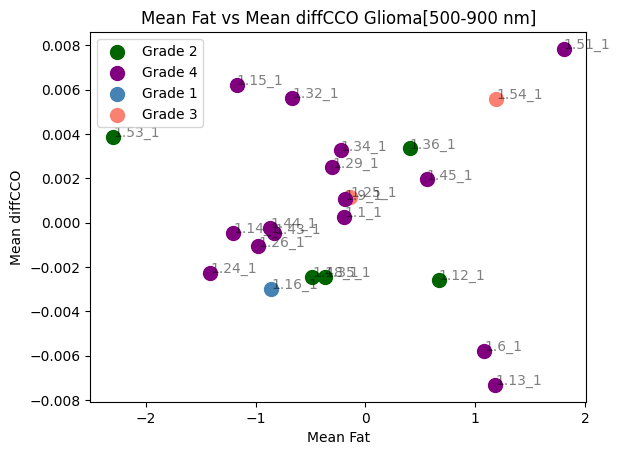

In [6]:
color_map = {'1': "steelblue", '2': "darkgreen", '3': "salmon", '4': "purple"}

unique_labels = {}
processed_patients = []
texts = []
path = '../results/biopsy2_spectral_unmixing/glioma_avgpool_4_coarseness_1_left_500_right_900'
display_all_samples = False
display_fat_vs_diff_cco = True

for sample in dataset.cube_samples:
    if sample['patient_id'] in processed_patients and not display_all_samples:
        continue
    if sample["metadata"]["type_of_tumor"] == "Glioma":
        processed_patients.append(sample['patient_id'])
        code = sample["metadata"]["grading"]
        color = color_map.get(code, "black")
        if color == "black":
            print(f"Unknown grading code {code} for sample {sample['id']}")
            continue
        label = f"Grade {code}"
        coeff_list, _ = dataset.load_delta_c_and_scatter_params(
            id=sample["id"],
            load_from_path=path,
        )
        # delta_c = coeff_list.reshape(512, 512, -1)
        delta_c = coeff_list
        mean_fat, mean_diff_cco, mean_diff_hb = get_mean_fat_diff_cco_diff_hb(delta_c, crop=None)
        label = f"Grade {code}"
        if code not in unique_labels:
            unique_labels[code] = label
            if display_fat_vs_diff_cco:
                plt.scatter(mean_fat, mean_diff_cco, color=color, label=label, s=100)
            else:
                plt.scatter(mean_fat, mean_diff_hb, color=color, label=label, s=100)
        else:
            if display_fat_vs_diff_cco:
                plt.scatter(mean_fat, mean_diff_cco, color=color, s=100)
            else:
                plt.scatter(mean_fat, mean_diff_hb, color=color, s=100)
        print(f"Sample {sample['id']}, Grade {sample['metadata']['grading']}:")

        # plt.scatter(mean_fat, mean_diff_cco, label=f'{sample["id"]}', color=get_grade_color(sample['metadata']['grading']))
        if display_fat_vs_diff_cco:
            plt.text(mean_fat, mean_diff_cco, sample["id"], alpha=0.5)
        else:
            plt.text(mean_fat, mean_diff_hb, sample["id"], alpha=0.5)


plt.xlabel("Mean Fat")
if display_fat_vs_diff_cco:
    plt.ylabel("Mean diffCCO")
    plt.title("Mean Fat vs Mean diffCCO Glioma[500-900 nm]")
else:
    plt.ylabel("Mean diffHB")
    plt.title("Mean Fat vs Mean diffHB Glioma[500-900 nm]")
plt.legend()

### 3D Plot

Unknown grading code nan for sample 1.55_1
Unknown grading code nan for sample 1.56_1
Unknown grading code nan for sample 1.57_1
Unknown grading code nan for sample 1.58_1


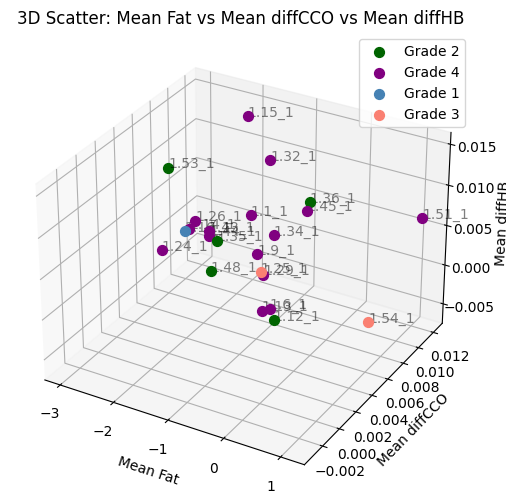

In [7]:
from mpl_toolkits.mplot3d import Axes3D

# 3D scatter plot of Mean Fat, Mean diffCCO, Mean diffHB
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

color_map = {'1': "steelblue", '2': "darkgreen", '3': "salmon", '4': "purple"}

unique_labels = {}
processed_patients = []
# path = '../results/spectral_unmixing_avgpool_4_left_500_right_995'
path = '../results/biopsy2_spectral_unmixing/spectral_unmixing_avgpool_4_coarseness_1_left_500_right_900_t1_all_molecules'


for sample in dataset.cube_samples:
    if sample['patient_id'] in processed_patients:
        continue
    if sample["metadata"]["type_of_tumor"] == "Glioma":
        processed_patients.append(sample['patient_id'])
        code = sample["metadata"]["grading"]
        color = color_map.get(code, "black")
        if color == "black":
            print(f"Unknown grading code {code} for sample {sample['id']}")
            continue
        coeff_list, _ = dataset.load_delta_c_and_scatter_params(
            id=sample["id"],
            load_from_path=path,
        )
        if coeff_list is None:
            print(f"No coefficients found for sample {sample['id']}")
            continue
        delta_c = coeff_list.reshape(512, 512, -1)
        mean_fat, mean_diff_cco, mean_diff_hb = get_mean_fat_diff_cco_diff_hb(delta_c)
        label = f"Grade {code}"
        if code not in unique_labels:
            unique_labels[code] = label
            ax.scatter(mean_fat, mean_diff_cco, mean_diff_hb, color=color, label=label, s=50)
        else:
            ax.scatter(mean_fat, mean_diff_cco, mean_diff_hb, color=color, s=50)
        ax.text(mean_fat, mean_diff_cco, mean_diff_hb, sample['id'], alpha=0.5)

ax.set_xlabel("Mean Fat")
ax.set_ylabel("Mean diffCCO")
ax.set_zlabel("Mean diffHB")
ax.set_title("3D Scatter: Mean Fat vs Mean diffCCO vs Mean diffHB")
ax.legend()
plt.show()

### PCA Decomposition

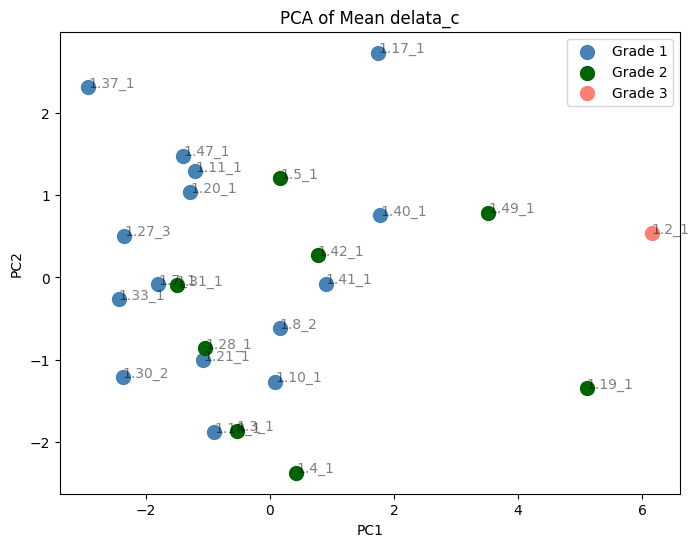

In [9]:
# Prepare data and labels
color_map = {"1": "steelblue", "2": "darkgreen", "3": "salmon"}
unique_labels = {}
processed_patients = []
path = '../results/spectral_unmixing_avgpool_4_coarseness_1_left_500_right_900_absolute'
X = []
codes = []
ids = []

for sample in dataset.cube_samples:
    if sample['patient_id'] in processed_patients:
        continue
    if sample['metadata']['type_of_tumor'] == 'Mening':
        processed_patients.append(sample['patient_id'])
        code = sample['metadata']['grading']
        if code not in color_map:
            print(f"Unknown grading code {code} for sample {sample['id']}")
            continue
        coeff_list, _ = dataset.load_delta_c_and_scatter_params(
            id=sample['id'],
            load_from_path=path,
        )
        delta_c = coeff_list.reshape(512, 512, -1)
        mean_data = get_mean_data(delta_c)
        X.append(mean_data)
        codes.append(code)
        ids.append(sample['id'])

# Convert to array
X = np.array(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Plot PCA results
plt.figure(figsize=(8, 6))
for pc, code, id in zip(pcs, codes, ids):
    color = color_map[code]
    label = f"Grade {code}"
    if code not in unique_labels:
        unique_labels[code] = label
        plt.scatter(pc[0], pc[1], color=color, label=label, s=100)
    else:
        plt.scatter(pc[0], pc[1], color=color, s=100)
    plt.text(pc[0], pc[1], id, alpha=0.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Mean delata_c')
plt.legend()
plt.show()

### Display arbitrary concentrations

Sample 1.10_1, Grade 1:
Sample 1.10_2, Grade 1:
Sample 1.11_1, Grade 1:
Sample 1.11_2, Grade 1:
Sample 1.11_3, Grade 1:
Sample 1.17_1, Grade 1:
Sample 1.18_1, Grade 1:
Sample 1.19_1, Grade 2:
Sample 1.19_14, Grade 2:
Sample 1.19_4, Grade 2:
Sample 1.19_5, Grade 2:
Sample 1.20_1, Grade 1:
Sample 1.21_1, Grade 1:
Sample 1.27_3, Grade 1:
Sample 1.28_1, Grade 2:
Sample 1.28_2, Grade 2:
Sample 1.2_1, Grade 3:
Sample 1.2_2, Grade 3:
Sample 1.2_3, Grade 3:
Sample 1.2_4, Grade 3:
Sample 1.30_2, Grade 1:
Sample 1.31_1, Grade 2:
Sample 1.33_1, Grade 1:
Sample 1.37_1, Grade 1:
Sample 1.3_1, Grade 2:
Sample 1.3_2, Grade 2:
Sample 1.3_3, Grade 2:
Sample 1.3_4, Grade 2:
Sample 1.3_5, Grade 2:
Sample 1.3_6, Grade 2:
Sample 1.3_7, Grade 2:
Sample 1.40_1, Grade 1:
Sample 1.41_1, Grade 1:
Sample 1.41_2, Grade 1:
Sample 1.42_1, Grade 2:
Sample 1.47_1, Grade 1:
Sample 1.49_1, Grade 2:
Sample 1.49_2, Grade 2:
Sample 1.4_1, Grade 2:
Sample 1.4_2, Grade 2:
Sample 1.4_3, Grade 2:
Sample 1.4_4, Grade 2:
Sample

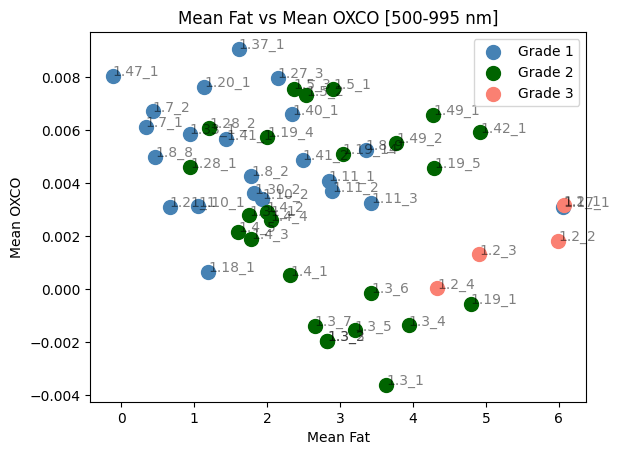

In [ ]:
color_map = {"1": "steelblue", "2": "darkgreen", "3": "salmon"}
unique_labels = {}
processed_patients = []
texts = []
path = '../results/spectral_unmixing_avgpool_4_coarseness_1_left_500_right_900_absolute/'
display_all_samples = True

for sample in dataset.cube_samples:
    if sample["patient_id"] in processed_patients and not display_all_samples:
        continue
    if sample["metadata"]["type_of_tumor"] == "Mening":
        processed_patients.append(sample['patient_id'])
        code = sample["metadata"]["grading"]
        color = color_map.get(code, "black")
        if color == "black":
            print(f"Unknown grading code {code} for sample {sample['id']}")
            continue
        label = f"Grade {code}"
        coeff_list, _ = dataset.load_delta_c_and_scatter_params(
            id=sample["id"],
            load_from_path=path,
        )
        delta_c = coeff_list.reshape(512, 512, -1)
        mean_data = get_mean_data(delta_c)
        mean_fat = mean_data[MoleculeIndex.FAT]
        mean_oxco = mean_data[MoleculeIndex.COXA]
        label = f"Grade {code}"
        if code not in unique_labels:
            unique_labels[code] = label
            plt.scatter(mean_fat, mean_oxco, color=color, label=label, s=100)
        else:
            plt.scatter(mean_fat, mean_oxco, color=color, s=100)
        print(f"Sample {sample['id']}, Grade {sample['metadata']['grading']}:")

        plt.text(mean_fat, mean_oxco, sample["id"], alpha=0.5)

plt.xlabel("Mean Fat")
plt.ylabel("Mean OXCO")
plt.title("Mean Fat vs Mean OXCO [500-900 nm]")
plt.legend()

## Comparison to Hyperprobe Biopsy Data as Check

In [11]:
biopsy1_dataset = Biopsy1Dataset(coarseness=8)

sample = biopsy1_dataset[0]
print(sample['delta_A'].shape)
print(sample.keys())

(64, 64, 79)
dict_keys(['id', 'file_path', 'hsi_cube', 'delta_A'])


### Spectral Unmixing

In [7]:

save_dir = Path(
    f"../results/spectral_unmixing_biopsy_coarseness_8_all_molecules"
)
save_dir.mkdir(parents=True, exist_ok=True)
molecules = Molecules(left_cut=510, right_cut=900)
t1_params = [
    REFERENCE_SPECTRUM_T1[MoleculeMode.ALL][0],
    REFERENCE_SPECTRUM_T1[MoleculeMode.ALL][1],
]


for sample in tqdm(biopsy1_dataset):
    print("Processing sample:", sample["id"])
    orig_path = Path(sample['file_path'])
    sample_dir = save_dir / orig_path.stem

    if sample_dir.exists():
        print(f"Sample {orig_path.stem} already processed. Skipping.")
        continue
    
    delta_A = sample['delta_A']
    delta_A_flat = delta_A.reshape(-1, delta_A.shape[-1])


    errors, coef_list, scatter_params, _ = optimize_image_parallel(
        t1_params, delta_A_flat, molecules.M, biopsy1_dataset.cut_wavelengths
    )

    # --- Store results for each sample ---
    # Get original file name without extension
    sample_dir.mkdir(parents=True, exist_ok=True)

    # Save errors, coef_list, scatter_params as .npy files
    np.save(sample_dir / 'errors.npy', errors)
    np.save(sample_dir / 'coef_list.npy', coef_list)
    np.save(sample_dir / 'scatter_params.npy', scatter_params)

  0%|          | 0/12 [00:00<?, ?it/s]

Processing sample: S1


  8%|▊         | 1/12 [00:02<00:22,  2.01s/it]

Processing sample: S10


 17%|█▋        | 2/12 [00:04<00:21,  2.17s/it]

...

 83%|████████▎ | 10/12 [00:21<00:04,  2.22s/it]

Processing sample: S8


 92%|█████████▏| 11/12 [00:23<00:02,  2.16s/it]

Processing sample: S9


100%|██████████| 12/12 [00:26<00:00,  2.17s/it]


### Display inferred concentrations

(4096, 10)


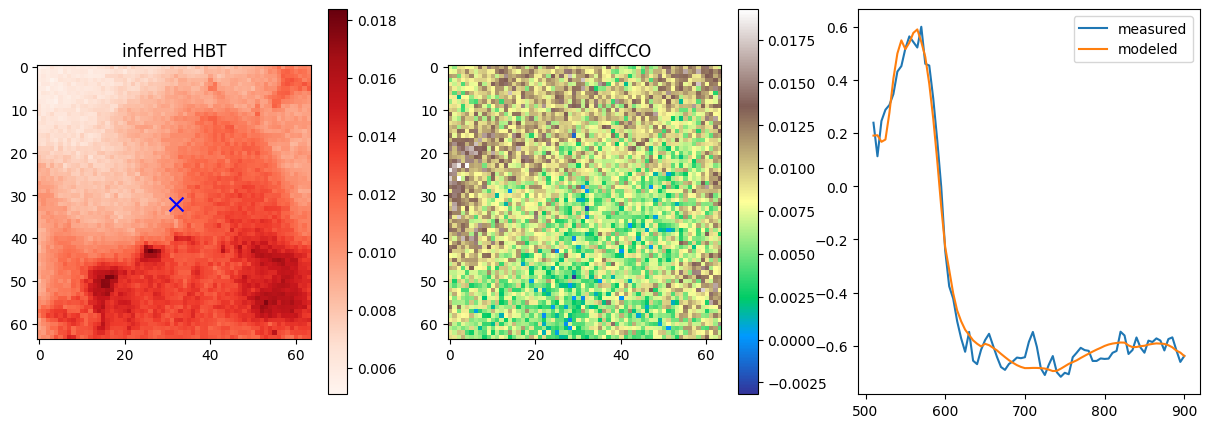

In [13]:
from src.scattering_model.scatter import compute_delta_A_img

id = "S4_1"
delta_c, scatter_params = biopsy1_dataset.load_delta_c_and_scatter_params(
    id=id,
    load_from_path="../results/spectral_unmixing_biopsy_coarseness_8_all_molecules",
)

print(delta_c.shape)

delta_A = biopsy1_dataset.get_sample_by_id(sample_id=id)["delta_A"]

scatter_delta_c = delta_c.reshape(delta_A.shape[0], delta_A.shape[1], -1)
scatter_params = scatter_params.reshape(delta_A.shape[0], delta_A.shape[1], -1)

modeled_delta_A = compute_delta_A_img(
    M=molecules.M,
    delta_c=scatter_delta_c,
    a=scatter_params[:, :, 0],
    b=scatter_params[:, :, 1],
    a_0=t1_params[0],
    b_0=t1_params[1],
    x=biopsy1_dataset.cut_wavelengths,
)

spectrum_pxl = 32, 32

plot_inferred_concentrations(
    spectrum_pxl,
    scatter_delta_c,
    delta_A,
    modeled_delta_A,
    biopsy1_dataset.cut_wavelengths,
)

### Separation Plots

Sample S1, mean fat: -0.10857766291364734, mean diffCCO: 0.0010015907399812019
Sample S10, mean fat: -2.4513221264468577, mean diffCCO: 0.0015133034014337661
Sample S11, mean fat: -1.811796655871722, mean diffCCO: 0.002491954066945738
Sample S2, mean fat: 1.658286366177225, mean diffCCO: 0.003293514244295082
Sample S4_1, mean fat: -1.9281323297069246, mean diffCCO: 0.00823692890549629
Sample S4_2, mean fat: -0.6935597931096643, mean diffCCO: 0.0035521594153200414
Sample S5, mean fat: 2.1025851289310964, mean diffCCO: 0.012574557371673463
Sample S7, mean fat: -3.1773210871431976, mean diffCCO: 0.004081620333939117
Sample S8, mean fat: -2.4002854932544757, mean diffCCO: 0.005186890022546419
Sample S9, mean fat: -0.2010738617923899, mean diffCCO: 0.0028127580913539967


Text(0.5, 1.0, 'Mean Fat vs Mean diffCCO')

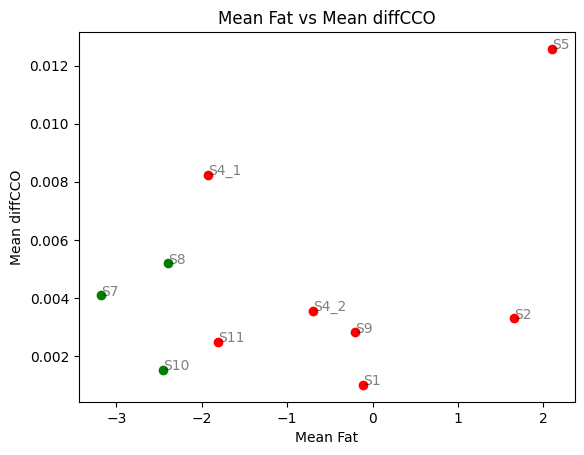

In [ ]:
def get_grade_color(id):
    if id=='S7' or id=='S8' or id=='S10':
        return "green"
    else:
        return "red"

for sample in biopsy1_dataset.sample_map:
    if sample == 'S3' or sample == 'S6':
        continue
    coeff_list, _ = biopsy1_dataset.load_delta_c_and_scatter_params(
        id=sample,
        load_from_path="../results/spectral_unmixing_biopsy_coarseness_8_all_molecules",
    )
    delta_c = coeff_list.reshape(
        64, 64, -1
    )
    mean_fat, mean_diff_cco, mean_hbo2 = get_mean_fat_diff_cco_hbo2(delta_c)
    print(f"Sample {sample}, mean fat: {mean_fat}, mean diffCCO: {mean_diff_cco}")
    plt.scatter(mean_fat, mean_diff_cco, label=f'{sample}', color=get_grade_color(sample))
    plt.text(mean_fat, mean_diff_cco, sample, alpha=0.5)

plt.xlabel("Mean Fat")
plt.ylabel("Mean diffCCO")
plt.title("Mean Fat vs Mean diffCCO")


Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S1_reflectance_preprocessed for S1
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S10_reflectance_preprocessed for S10
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S11_reflectance_preprocessed for S11
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S2_reflectance_preprocessed for S2
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S3_reflectance_preprocessed for S3
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S4_fov1_reflectance_preprocessed for S4_1
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe_biopsy/Biopsy_S4_fov2_reflectance_preprocessed for S4_2
Loading delta C and scatter params from ../results/spectral_unmixing_hyperprobe

Text(0.5, 1.0, 'Mean diffCCO vs Mean Hbo2')

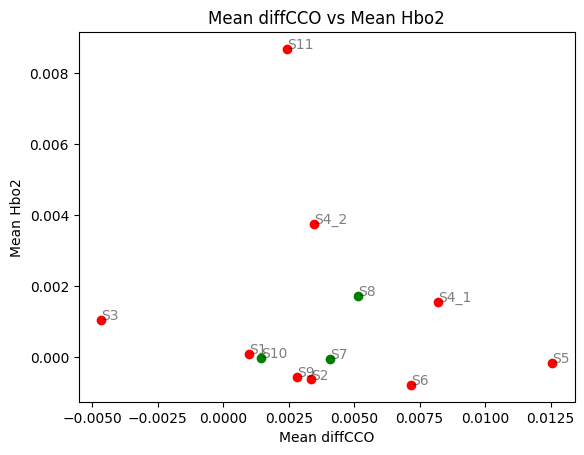

In [14]:
for sample in biopsy1_dataset.sample_map:
    coeff_list, _ = biopsy1_dataset.load_delta_c_and_scatter_params(
        id=sample,
        load_from_path="../results/spectral_unmixing_hyperprobe_biopsy/",
    )
    delta_c = coeff_list.reshape(512, 512, -1)
    mean_fat, mean_diff_cco, mean_hbo2 = get_mean_fat_diff_cco_hbo2(delta_c)
    plt.scatter(
        mean_diff_cco, mean_hbo2, label=f"{sample}", color=get_grade_color(sample)
    )
    plt.text(mean_diff_cco, mean_hbo2, sample, alpha=0.5)

plt.xlabel("Mean diffCCO")
plt.ylabel("Mean Hbo2")
plt.title("Mean diffCCO vs Mean Hbo2")

In [ ]:
id = "1.12_2"
coeff_list_1, scatter_1 = dataset.load_delta_c_and_scatter_params(
    id=id,
    load_from_path="../results/spectral_unmixing_avgpool_4_left_630_right_995",
)

coeff_list_2, scatter_2 = dataset.load_delta_c_and_scatter_params(
    id=id,
    load_from_path="../results/spectral_unmixing_avgpool_4_left_630_right_995_new_optimizer",
)

print(np.array_equal(coeff_list_1, coeff_list_2))
print(np.array_equal(scatter_1, scatter_2))

True
True
